# 07. 応用 — グラフ・Markov 連鎖・金融・量子

| 層 | セクション |
|---|---|
| Basic | 1. Big Picture 〜 3. Intuition |
| Applied | 4〜7(各応用)、10. Exercises |
| Advanced | 8. Invariant / 9. Failure Mode の一部、11. Advanced Notes |

## 1. Big Picture

最終章では、ここまでの道具一式(固有値・べき乗・二次形式・PCA・スペクトル定理)を
4 つの全く違う世界に持ち込みます。

| 世界 | 行列 | 固有値が答える問い |
|---|---|---|
| Web・Markov 連鎖 | 遷移行列 | 長期的にどこに落ち着くか(PageRank) |
| グラフ・ネットワーク | ラプラシアン | どこで切れば自然に分かれるか(クラスタリング) |
| 金融 | 共分散行列 | リスクはどの方向に集中しているか(ファクター) |
| 量子力学 | Hermitian / Unitary | 観測で得られる値は何か |

**違う現象、同じ線形代数。** これがこの教材の締めくくりのメッセージです。

## 2. Problem — 4 つの問い

1. **Web 検索**: リンクだらけの Web で、どのページが「重要」か?
   「重要なページからリンクされるページは重要」という循環した定義に意味を与えられるか?
2. **コミュニティ検出**: SNS の友人関係グラフを、自然な 2 グループに分けたい。
   どの辺を切るべきか?
3. **ポートフォリオ**: 6 銘柄に資金を配分する。全体のリスク(分散)はいくつか?
   分散投資はなぜ・どこまで効くのか?
4. **量子状態**: 量子ビットの状態はベクトルで表されるという。
   「観測」や「時間発展」は線形代数の言葉で何にあたるのか?

## 3. Intuition — すべて「固有値の問題」になる

- PageRank: 「重要度の定義が循環している」=「重要度ベクトルは遷移行列の **固有ベクトル**」。
  03 章の人口移動と同じく、べき乗の収束先が答え。
- クラスタリング: 「切れ目」はグラフの **ラプラシアン行列の第 2 固有ベクトル** に現れる。
- ポートフォリオ: リスクは二次形式 $w^\top \Sigma w$。
  $\Sigma$ の **固有ベクトル** が「市場の独立な動き」、固有値がその大きさ。
- 量子: 観測値は **Hermitian 行列の固有値**、時間発展は **Unitary 行列**(長さを保存する変換)。

In [1]:
# Shared setup.
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import plotly.io as pio

from la_book import algebra, plotting
from la_book.datasets import (
    make_asset_returns, make_two_cluster_graph, make_web_graph, make_yield_curves,
)
from la_book.decompositions import pca_fit

# Render Plotly both in JupyterLab and in the static Jupyter Book HTML.
pio.renderers.default = "plotly_mimetype+notebook_connected"
np.set_printoptions(precision=4, suppress=True)

## 4. Markov 連鎖と PageRank

### Markov 連鎖 — 確率の流れ

状態間の遷移確率を並べた行列 $P$(各行の和 = 1、**確率行列**)で記述されるシステムです。
天気(晴・曇・雨)の例で、分布のべき乗収束と **定常分布**($\pi P = \pi$、
つまり固有値 1 の左固有ベクトル)を確認します。

stationary distribution: {'sunny': np.float64(0.4615), 'cloudy': np.float64(0.3077), 'rainy': np.float64(0.2308)}
check pi P = pi: [0.4615 0.3077 0.2308]


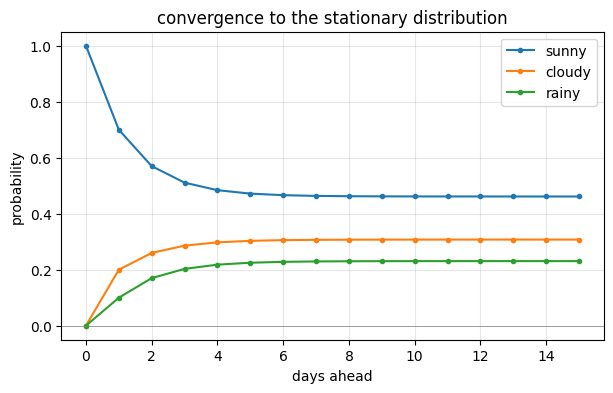

In [2]:
# A 3-state weather Markov chain: rows = today, columns = tomorrow.
P = np.array([[0.7, 0.2, 0.1],    # sunny ->
              [0.3, 0.4, 0.3],    # cloudy ->
              [0.2, 0.4, 0.4]])   # rainy ->
states = ["sunny", "cloudy", "rainy"]

pi = algebra.markov_stationary(P)
print("stationary distribution:", dict(zip(states, pi.round(4))))
print("check pi P = pi:", pi @ P)

# Any starting distribution converges to pi.
dist = np.array([1.0, 0.0, 0.0])     # certainly sunny today
hist = [dist]
for _ in range(15):
    dist = dist @ P
    hist.append(dist)
hist = np.array(hist)

plt.figure(figsize=(7, 4))
for j, s in enumerate(states):
    plt.plot(hist[:, j], "o-", ms=3, label=s)
plt.axhline(0, color="gray", lw=0.5)
plt.xlabel("days ahead"); plt.ylabel("probability")
plt.grid(alpha=0.3); plt.legend()
plt.title("convergence to the stationary distribution")
plt.show()

### PageRank — Web 全体を 1 つの Markov 連鎖と見る

「ランダムにリンクをクリックし続けるネットサーファーが、長期的に各ページにいる確率」が
PageRank です。確率 $d = 0.85$ でリンクを辿り、$1 - d$ でランダムなページに飛ぶ
(**Google 行列**)ことで、行き止まり・孤立の問題を解消しています。

$$
G = d\,T + \frac{1 - d}{n}\,\mathbf{1}\mathbf{1}^\top
$$

計算はべき乗法(03 章)そのもの。7 ページの小さな Web で実行します。

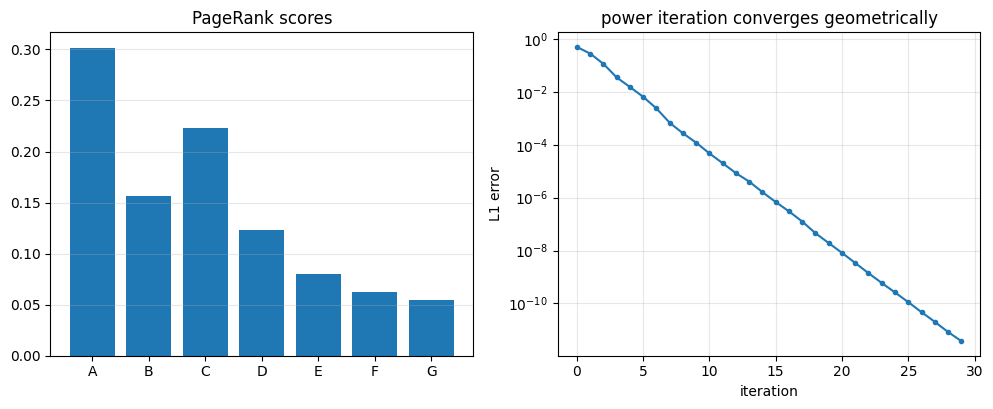

ranking: ['A (0.302)', 'C (0.223)', 'B (0.156)', 'D (0.123)', 'E (0.080)', 'F (0.062)', 'G (0.054)']


In [3]:
# PageRank on a small web graph (A is the hub, G is a dangling page).
names, adj = make_web_graph()
ranks, history = algebra.page_rank(adj, return_history=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].bar(names, ranks, color="#1f77b4")
axes[0].set_title("PageRank scores")
axes[0].grid(alpha=0.3, axis="y")

# Convergence of the power iteration: error vs the final vector.
err = np.abs(history - ranks).sum(axis=1)
axes[1].semilogy(err[:30], "o-", ms=3)
axes[1].set_title("power iteration converges geometrically")
axes[1].set_xlabel("iteration"); axes[1].set_ylabel("L1 error")
axes[1].grid(alpha=0.3, which="both")
plt.show()

order = np.argsort(ranks)[::-1]
print("ranking:", [f"{names[i]} ({ranks[i]:.3f})" for i in order])

## 5. グラフ・ラプラシアンとスペクトルクラスタリング

無向グラフは **隣接行列** $A$(つながっていれば 1)で表せます。
次数(つながりの本数)を対角に並べた $D$ との差

$$
L = D - A
$$

が **グラフラプラシアン** です。重要な性質:任意のベクトル $x$(各頂点に数を割り当てたもの)に対し

$$
x^\top L x = \sum_{(i,j) \in E} (x_i - x_j)^2
$$

つまり $x^\top L x$ は「辺の両端での値の食い違いの総量」。
これが小さい $x$ は「つながりの濃い頂点グループ内でほぼ一定」になるしかありません。

- 最小固有値は常に 0(固有ベクトルは全成分 1 = 全部同じ値なら食い違いゼロ)
- **2 番目に小さい固有値の固有ベクトル(Fiedler ベクトル)** が、
  「なるべく食い違いを増やさずに 2 グループに塗り分ける」最良の塗り方を教えてくれます。
  符号で割ればクラスタリング完成です。

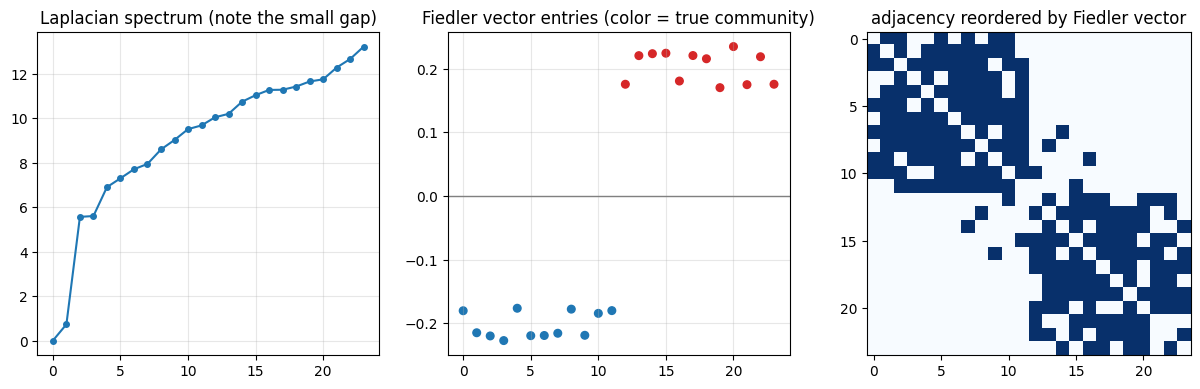

clustering accuracy vs ground truth: 100%


In [4]:
# Spectral clustering: the Fiedler vector splits a two-community graph.
adj, true_labels = make_two_cluster_graph(n_per=12, p_in=0.8, p_out=0.05, seed=3)
D = np.diag(adj.sum(axis=1))
L = D - adj

eigvals, eigvecs = np.linalg.eigh(L)       # symmetric -> eigh
fiedler = eigvecs[:, 1]                    # eigenvector of the 2nd smallest eigenvalue
pred = (fiedler > 0).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].plot(eigvals, "o-", ms=4)
axes[0].set_title("Laplacian spectrum (note the small gap)")
axes[0].grid(alpha=0.3)

colors = np.where(true_labels == 0, "#1f77b4", "#d62728")
axes[1].scatter(range(len(fiedler)), fiedler, c=colors, s=30)
axes[1].axhline(0, color="gray", lw=1)
axes[1].set_title("Fiedler vector entries (color = true community)")
axes[1].grid(alpha=0.3)

# Adjacency matrix reordered by the Fiedler values: block structure appears.
order = np.argsort(fiedler)
axes[2].imshow(adj[np.ix_(order, order)], cmap="Blues")
axes[2].set_title("adjacency reordered by Fiedler vector")
plt.show()

agree = max((pred == true_labels).mean(), (pred != true_labels).mean())
print(f"clustering accuracy vs ground truth: {agree:.0%}")

## 6. 金融 — 共分散行列・ポートフォリオ・金利カーブ PCA

### リターン行列から共分散・相関へ

日次リターンの行列(行 = 日、列 = 資産)から、**共分散行列** $\Sigma$ と
**相関行列** を作ります。これが金融リスク管理の基本素材です。

      TECH1     TECH2     BANK1     BANK2     UTIL1     BOND1
0  0.008232  0.000190 -0.005557 -0.003017  0.007563 -0.006340
1  0.010534  0.000950  0.011837  0.014100  0.003318 -0.006254
2 -0.016253 -0.011727  0.010329  0.012823  0.003247  0.007360


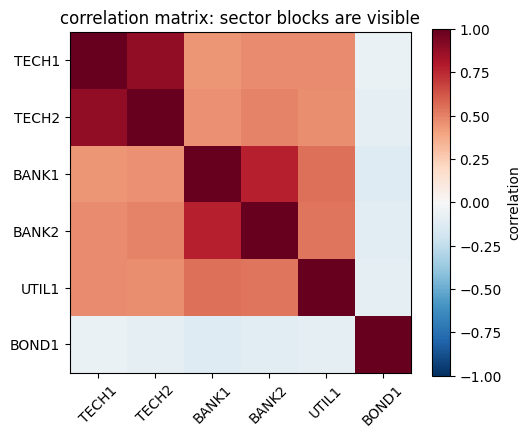

In [5]:
# Daily returns for 6 assets (synthetic, factor-driven): the raw material.
returns = make_asset_returns(n_days=750, seed=7)
print(returns.head(3))

Sigma = returns.cov().to_numpy()           # covariance matrix
corr = returns.corr()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(6), returns.columns, rotation=45)
ax.set_yticks(range(6), returns.columns)
fig.colorbar(im, label="correlation")
ax.set_title("correlation matrix: sector blocks are visible")
plt.show()

### ポートフォリオ分散は二次形式

資産への配分比率(ウェイト)$w$ のポートフォリオの分散は

$$
\sigma_p^2 = w^\top \Sigma w
$$

**ポートフォリオのリスクは、共分散行列が定める二次形式の値** です。
$\Sigma$ が半正定値(固有値がすべて $\ge 0$)だから、分散は決して負になりません。
分散投資の効果も計算で見えます。

In [6]:
# Portfolio variance sigma_p^2 = w' Sigma w: concentration vs diversification.
w_conc = np.array([1.0, 0.0, 0.0, 0.0, 0.0, 0.0])    # all-in on TECH1
w_eq = np.full(6, 1 / 6)                              # equal weight

for name, w in [("100% TECH1", w_conc), ("equal weight", w_eq)]:
    var_p = w @ Sigma @ w
    print(f"{name:>12}: annualized vol = {np.sqrt(252 * var_p):.1%}")

  100% TECH1: annualized vol = 28.2%
equal weight: annualized vol = 14.7%


### 固有値分解によるリスクファクター分解

$\Sigma = Q \Lambda Q^\top$(スペクトル定理)と分解すると:

- 固有ベクトル $q_i$ = 互いに無相関な「市場の動きのモード」(リスクファクター)
- 固有値 $\lambda_i$ = そのモードの分散

ポートフォリオのリスクをファクターごとに分けられます:

$$
\sigma_p^2 = \sum_i \lambda_i (q_i^\top w)^2
$$

In [7]:
# Eigen-decomposition of the covariance: independent risk factors.
lam, Q = np.linalg.eigh(Sigma)
lam, Q = lam[::-1], Q[:, ::-1]            # sort descending

print("factor variances (eigenvalues):", lam)
print("variance share of factor 1   :", lam[0] / lam.sum())
print("\nfactor 1 loadings (the 'market' mode):")
print(pd.Series(Q[:, 0], index=returns.columns).round(3))

# Risk decomposition of the equal-weight portfolio.
exposures = Q.T @ w_eq
contrib = lam * exposures**2
print("\nrisk contribution by factor:", (contrib / contrib.sum()).round(3))
print("check sum = w' Sigma w:", np.isclose(contrib.sum(), w_eq @ Sigma @ w_eq))

factor variances (eigenvalues): [0.0007 0.0002 0.     0.     0.     0.    ]
variance share of factor 1   : 0.6815341919372927

factor 1 loadings (the 'market' mode):
TECH1   -0.622
TECH2   -0.603
BANK1   -0.347
BANK2   -0.304
UTIL1   -0.189
BOND1    0.026
dtype: float64

risk contribution by factor: [0.958 0.024 0.003 0.012 0.    0.002]
check sum = w' Sigma w: True


### 金利カーブ PCA — Level / Slope / Curvature

国債利回りは満期ごとに 1 本ずつあり(イールドカーブ)、毎日まとめて動きます。
日次変化を PCA すると、世界中の市場で繰り返し観測される 3 つの主成分が現れます。

- **PC1 Level(水平移動)**: 全満期が同方向に動く。全分散の大半を占める。
- **PC2 Slope(傾き)**: 短期と長期が逆方向に動く(スティープ化・フラット化)。
- **PC3 Curvature(曲率)**: 中期だけが逆に動く(バタフライ)。

合成した金利カーブパネル(500 営業日 × 10 満期)で再現します。まずデータを眺めます。

In [8]:
# Synthetic yield-curve panel: sampled curves from oldest (light) to newest (dark).
mats, curves = make_yield_curves(n_days=500, seed=42)
fig = plotting.plotly_yield_curves(mats, curves.to_numpy(), every=25)
fig.show()

In [9]:
# PCA on daily changes of the curve.
changes = curves.diff().dropna().to_numpy()
res = pca_fit(changes, n_components=3)

print("explained variance ratio:", res.explained_variance_ratio[:3].round(3))
print("cumulative              :", res.explained_variance_ratio[:3].cumsum().round(3))

explained variance ratio: [0.973 0.018 0.002]
cumulative              : [0.973 0.991 0.993]


In [10]:
# The three famous shapes: Level / Slope / Curvature loadings across maturities.
fig = plotting.plotly_pca_loadings(mats, res.components[:3])
fig.show()

PC1 は全満期でほぼ一定(Level)、PC2 は短期と長期で符号が逆(Slope)、
PC3 は中期に山(Curvature)。
実務では、債券ポートフォリオのリスクを「Level リスク・Slope リスク」に集約したり、
カーブ全体のシナリオを 3 パラメータで生成したりするのに使われています。

## 7. 量子状態への導入 — Hermitian と Unitary

量子力学は複素ベクトル空間の線形代数です。対応表:

| 物理 | 線形代数 |
|---|---|
| 状態 | 単位ベクトル $\|\psi\rangle \in \mathbb{C}^n$ |
| 観測可能量 | **Hermitian 行列** $H = H^\dagger$(共役転置で不変) |
| 観測値 | $H$ の **固有値**(Hermitian なので必ず実数) |
| 観測確率 | 状態を固有ベクトル基底で展開した係数の絶対値の 2 乗 |
| 時間発展・ゲート | **Unitary 行列** $U^\dagger U = I$(長さ = 確率の合計を保存) |

最小の例 **量子ビット**: $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$、
$|\alpha|^2 + |\beta|^2 = 1$。測定すると確率 $|\alpha|^2$ で 0、$|\beta|^2$ で 1 が得られます。

In [11]:
# Qubit basics with Pauli matrices: Hermitian (observables) and unitary (gates).
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)
H_gate = (sigma_x + sigma_z) / np.sqrt(2)          # Hadamard gate

# Hermitian check and real eigenvalues (the possible measurement outcomes).
print("sigma_z Hermitian:", np.allclose(sigma_z, sigma_z.conj().T))
print("eigenvalues of sigma_z:", np.linalg.eigvalsh(sigma_z), "(measurement outcomes)")

# Unitary check: gates preserve the norm (= total probability).
print("H unitary:", np.allclose(H_gate.conj().T @ H_gate, np.eye(2)))

ket0 = np.array([1.0, 0.0], dtype=complex)
psi = H_gate @ ket0                                # put |0> into superposition
print("\n|psi> = H|0> =", psi)
print("measurement probabilities:", np.abs(psi) ** 2, "(fair coin)")
print("norm preserved:", np.linalg.norm(psi))

sigma_z Hermitian: True
eigenvalues of sigma_z: [-1.  1.] (measurement outcomes)
H unitary: True

|psi> = H|0> = [0.7071+0.j 0.7071+0.j]
measurement probabilities: [0.5 0.5] (fair coin)
norm preserved: 0.9999999999999999


In [12]:
# Expectation value of an observable: <psi| H |psi>.
exp_z = np.real(psi.conj() @ sigma_z @ psi)
exp_x = np.real(psi.conj() @ sigma_x @ psi)
print("<sigma_z> =", round(exp_z, 10), " (0 and 1 equally likely)")
print("<sigma_x> =", round(exp_x, 10), " (psi IS an eigenvector of sigma_x)")

<sigma_z> = 0.0  (0 and 1 equally likely)
<sigma_x> = 1.0  (psi IS an eigenvector of sigma_x)


ここで使ったのは、05 章のスペクトル定理(Hermitian は実固有値・直交固有ベクトル)と
04 章の「直交行列は長さを保存する」の複素版だけです。
量子計算の「ゲートを並べる」は Unitary 行列の積、すなわち 01 章の「変換の合成」です。

## 8. Invariant — 4 つの世界の保存量

| 世界 | 保存されるもの | 守っている構造 |
|---|---|---|
| Markov / PageRank | 確率の合計 1 | 確率行列(行和 1)、固有値 1 |
| グラフ | $x^\top L x \ge 0$、連結成分数 = 固有値 0 の重複度 | ラプラシアンの半正定値性 |
| 金融 | 分散 $\ge 0$、全分散(trace $\Sigma$)は PCA で不変 | 共分散行列の半正定値性 |
| 量子 | 確率の合計(ノルム) | Unitary 性 |

どの世界でも「**保存量を壊さない変換のクラス**」が主役でした。
線形代数が応用先を選ばないのは、この「構造 + 保存量」という考え方が普遍的だからです。

## 9. Failure Mode — 各世界でモデルが壊れるとき

**Markov 連鎖**: 連結でない(行き来できない島がある)と定常分布が一意でなく、
周期的だと収束しません。PageRank の $(1-d)/n$ 項は、まさにこの 2 つを強制的に治す薬です。

**スペクトルクラスタリング**: コミュニティ構造が弱い(固有値ギャップが小さい)と
Fiedler ベクトルの符号が不安定になります。スペクトルのギャップが「分かれやすさ」の指標です。

**金融**: 資産数 $p$ に対して観測日数 $n$ が足りないと、標本共分散行列はランク落ちし
($n < p$ なら必ず特異)、最小分散ポートフォリオの計算(逆行列!)が暴走します。
06 章の条件数の問題が実務に直結する例で、リッジ型の正則化(縮小推定)が定番の対策です。

In [13]:
# Too few observations make the sample covariance singular and optimization explode.
rng = np.random.default_rng(1)
true_cov = Sigma                                  # 6x6 from before

for n_obs in [4, 10, 750]:
    sample = rng.multivariate_normal(np.zeros(6), true_cov, size=n_obs)
    S_hat = np.cov(sample.T)
    print(f"n = {n_obs:>3}: rank = {np.linalg.matrix_rank(S_hat)}, "
          f"cond = {np.linalg.cond(S_hat):.1e}")

n =   4: rank = 3, cond = 7.2e+16
n =  10: rank = 6, cond = 1.4e+03
n = 750: rank = 6, cond = 2.4e+01


## 10. Exercises

1. 天気の Markov 連鎖で、$P^k$($k = 1, 2, 5, 20$)を計算し、
   行がすべて定常分布に近づくことを確認せよ。
2. `make_web_graph` のリンクを 1 本書き換え(例: F→A を F→B に)、
   PageRank がどう変わるか観察せよ。「リンクを張る側」の変更が他ページに波及する理由を説明せよ。
3. ラプラシアンの固有値 0 の重複度がグラフの連結成分数に等しいことを、
   コミュニティ間の辺を全部消したグラフ($p_{\text{out}} = 0$)で確認せよ。
4. 2 資産(相関 $\rho$)の等ウェイトポートフォリオの分散を $\rho$ の関数として描き、
   分散投資の効果が $\rho$ にどう依存するか確認せよ。
5. 金利カーブ PCA を「変化分」でなく「水準」で行い、寄与率と主成分の形を比較せよ。
6. (発展)量子ゲート $R_\theta = \begin{pmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{pmatrix}$
   を $|0\rangle$ に作用させ、測定確率が $\theta$ とともにどう変わるかプロットせよ。

## 11. Advanced Notes

**Perron-Frobenius と PageRank の一意性。** Google 行列 $G$ は全成分が正なので、
Perron-Frobenius の定理より最大固有値 1 は単純で、対応する正の固有ベクトル(= PageRank)は
一意。さらに第 2 固有値は $|\lambda_2| \le d = 0.85$ で抑えられ、
べき乗法は毎反復 0.85 倍で収束します(上の片対数プロットの傾きがそれ)。

**正規化ラプラシアン。** 次数のばらつきが大きいグラフでは
$L_{\text{sym}} = D^{-1/2} L D^{-1/2}$ を使う方が安定です。
固有値は $[0, 2]$ に収まり、ランダムウォークの遷移行列 $D^{-1}A$ と同じスペクトル情報を持ちます。
3 クラスタ以上は「下位 $k$ 本の固有ベクトルを並べて k-means」が標準手順です。

**最小分散ポートフォリオと逆行列。** 制約 $\sum w_i = 1$ の下で $w^\top \Sigma w$ を
最小化すると $w^* = \Sigma^{-1}\mathbf{1} / (\mathbf{1}^\top \Sigma^{-1} \mathbf{1})$。
$\Sigma$ の条件数が悪いと $w^*$ は極端なロング・ショートになります。
実務では Ledoit-Wolf 縮小($\hat\Sigma = (1-\alpha)S + \alpha \mu I$ — リッジと同型)が定番です。

**金利 PCA の注意。** 水準での PCA は系列の非定常性(単位根)に引きずられ、
第 1 主成分が「ほぼ全部」を説明してしまいがちです。実務は変化分または対数変化分で行います。
また主成分の符号は任意なので、「Level = 全満期で正」になるよう符号を正規化して報告します。

**量子力学の続き。** 状態の時間発展は Schrödinger 方程式
$i\hbar \frac{d}{dt}|\psi\rangle = H |\psi\rangle$ に従い、解は $|\psi(t)\rangle = e^{-iHt/\hbar}|\psi(0)\rangle$。
Hermitian $H$ に対して $e^{-iHt}$ が Unitary になる(固有値が単位円上に乗る)ことは、
05 章のスペクトル定理から直ちに従います。行列指数関数は「対角化してから対角成分だけ
指数を取る」で計算でき、03 章のべき乗計算の連続版です。

## PageRank のべき乗反復(インタラクティブ)

小さな Web グラフの PageRank が、べき乗反復のステップを進めるごとに各ページの重要度へ収束する様子。スコアの合計は常に 1 に保たれる。

In [14]:
import plotly.io as pio
from la_book import plotting as viz

pio.renderers.default = "plotly_mimetype+notebook_connected"
fig = viz.plotly_pagerank()
fig.show()